# Forward Kinematics for the myCobot 280 Labs
## Lab 2: Manual and URDF-Based FK
Run this notebook from `~/venvs/mycobot`. Activate the environment with `source ~/venvs/mycobot/bin/activate` before starting Jupyter or any `ros2` commands.

This notebook continues the Lab 1 spatial-transformations workflow. You will build a simplified manual forward-kinematics model for the myCobot 280, compare it against a URDF-based model, and then use the live ROS 2 topics from the lab controller stack.


In [1]:
%matplotlib widget 
import numpy as np
from scipy.spatial.transform import Rotation as R
from spatialmath import SE3
from spatialmath.base import *
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH


### 1. DH parameters
Use the instructor-provided myCobot 280 geometry from the lab handout to define the classical parameters for a simplified manual FK model. If the exact values are not listed inside this notebook, insert the provided `a_i` and `d_i` values and complete the missing `dh_alpha` entries from your chosen frame assignment. Use the variable name `dh_alpha` in the code cell to avoid colliding with the `alpha` used in Task 2.

In [2]:
dh_alpha = np.array([np.pi/2, 0, 0, np.pi/2, -np.pi/2, 0])
print(dh_alpha)

[ 1.57079633  0.          0.          1.57079633 -1.57079633  0.        ]


### 2. Homogeneous transformation
Use the Lab 1 spatial-transformations workflow to build the homogeneous transform for the first joint/link of your manual myCobot 280 model. Evaluate it for `theta_1 = pi/4` using your classical parameters.


In [3]:
a=0
alpha=dh_alpha[0]
d=0.13122
theta=np.pi/4

trvecx=np.array([a, 0, 0])
trvecz=np.array([0, 0, d])

tformtx=transl(trvecx)
tformtz=transl(trvecz)
tformrotx=trotx(alpha)
tformrotz=trotz(theta)

shoulderlink=tformtz @ tformrotz @ tformtx @ tformrotx
print(shoulderlink)

[[ 7.07106781e-01 -4.32978028e-17  7.07106781e-01  0.00000000e+00]
 [ 7.07106781e-01  4.32978028e-17 -7.07106781e-01  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  6.12323400e-17  1.31220000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Manual FK Model
### 3. Base transform
Create a simplified base transform for the manual myCobot 280 model. Keep this manual/DH model separate from the later URDF import: in the real controller stack the kinematics are composed from URDF `origin xyz/rpy` transforms plus joint-axis rotations, with `g_base` as base link. For the myCobot 280, the DH base frame typically coincides with the URDF `g_base` frame at the robot's mounting surface. Start with the identity transform `SE3()` or a small vertical offset if your DH convention places frame 0 at a different height than the URDF origin.

In [4]:
base = SE3()

### 4. Define the first revolute link
Create a `RevoluteDH` link for the first myCobot 280 joint using the parameters from your handout. Use a simple manual name such as `joint1` or `link1`, assemble a one-link list, and create the first `DHRobot` object for your simplified manual DH model.


In [5]:
link1 = RevoluteDH(a=0, d=0.13122, alpha=dh_alpha[0], offset=0, name='joint1')
manual_links = [link1]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")

### 5. Verify the structure
Inspect the simplified manual DH model with `print(manual_robot)` and confirm that the first link and base transform match your intended myCobot 280 frame convention.


In [6]:
print(manual_robot)

DHRobot: myCobot280_manual, 1 joints (R), dynamics, standard DH parameters
┌─────┬────────┬────┬───────┐
│ θⱼ  │   dⱼ   │ aⱼ │  ⍺ⱼ   │
├─────┼────────┼────┼───────┤
│  q1 │ 0.1312 │  0 │ 90.0° │
└─────┴────────┴────┴───────┘



### 6. Add the remaining links
Extend the simplified manual myCobot 280 chain to six revolute joints with `RevoluteDH` links. Then rebuild the full chain as a `DHRobot`. Use generic manual link names such as `joint2` to `joint6` unless your lab handout specifies a different naming scheme.


In [7]:
link2 = RevoluteDH(a=-0.1104, d=0, alpha=dh_alpha[1], offset=-np.pi/2, name='joint2')
link3 = RevoluteDH(a=-0.096, d=0, alpha=dh_alpha[2], offset=0, name='joint3')
link4 = RevoluteDH(a=0, d=0.0634, alpha=dh_alpha[3], offset=-np.pi/2, name='joint4')
link5 = RevoluteDH(a=0, d=0.07505, alpha=dh_alpha[4], offset=np.pi/2, name='joint5')
link6 = RevoluteDH(a=0, d=0.0456, alpha=dh_alpha[5], offset=0, name='joint6')

manual_links = [link1, link2, link3, link4, link5, link6]
manual_robot = DHRobot(manual_links, base=base, name="myCobot280_manual")
print(manual_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



### 7. Add a manual end-effector frame
Add a final tool transform `manual_tool` for the simplified manual DH model. Start with the identity transform `SE3(np.eye(4))` so that this frame represents your classical end-effector reference before comparing it to the URDF model.


In [8]:
manual_tool = SE3(np.eye(4))

manual_robot = DHRobot(manual_links, base=base, tool=manual_tool, name="myCobot280_manual")

### 8. Verify structure
Print the completed simplified manual DH model and confirm that it contains the full six-joint myCobot 280 chain plus the tool frame.


In [9]:
print(manual_robot)


DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘



## URDF-Based Model
### 9. Import the myCobot 280 URDF
Import the myCobot 280 URDF-based model from the same folder as this notebook. In the tutor distribution, the file `mycobot_280_gazebo.urdf` is placed alongside the notebook. The URDF may reference mesh files (`.dae` or `.stl`) for visual geometry; these are not required for kinematic computation but must be present for 3D visualization. If meshes are missing, `rtb.Robot.URDF()` should still parse the kinematic chain, but 3D plotting may show incomplete or missing geometry. In the controller stack, the relevant base and end-effector links are `g_base` and `joint6_flange`.

In [10]:
import os
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
urdf_robot = rtb.Robot.URDF(mycobot_urdf_path)
print(urdf_robot)

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)                         │
│    6 │ joint5         │     3 │ joint4 │ SE3(-0.

/tmp/ipykernel_130458/1046804696.py:4: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  urdf_robot = rtb.Robot.URDF(mycobot_urdf_path)


**How the myCobot 280 controller computes FK (URDF style):**
Unlike the classical DH approach above, the actual `mycobot_control` ROS 2 node computes forward kinematics by walking the URDF joint chain from `g_base` to `joint6_flange`. For each joint in the chain it:

1. Applies the fixed frame offset: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{H}(\texttt{origin\_xyz}, \texttt{origin\_rpy})$
2. For revolute joints, applies the joint rotation about the local axis: $\boldsymbol{T} = \boldsymbol{T} \cdot \boldsymbol{R}(\texttt{axis}, q_i)$

where $\boldsymbol{H}(\texttt{xyz}, \texttt{rpy})$ builds a 4×4 homogeneous transform from the URDF `<origin xyz="..." rpy="..."/>` tag, and $\boldsymbol{R}(\texttt{axis}, q_i)$ is an axis-angle rotation about the joint's `<axis xyz="..."/>` vector. The composition principle — chaining transforms from base to end-effector — is the same as in the DH approach; only the parameterization of each link differs. The Lab 1 note on DH vs URDF convention connects to this distinction.

### 10. Compare both models
Print the simplified manual DH model and the imported URDF model. Identify the main structural differences between the simplified classical chain and the URDF-based myCobot 280 model.


In [11]:
print(manual_robot)
print(urdf_robot)

DHRobot: myCobot280_manual, 6 joints (RRRRRR), dynamics, standard DH parameters
┌───────────┬─────────┬─────────┬────────┐
│    θⱼ     │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├───────────┼─────────┼─────────┼────────┤
│  q1       │  0.1312 │       0 │  90.0° │
│  q2 - 90° │       0 │ -0.1104 │   0.0° │
│  q3       │       0 │  -0.096 │   0.0° │
│  q4 - 90° │  0.0634 │       0 │  90.0° │
│  q5 + 90° │ 0.07505 │       0 │ -90.0° │
│  q6       │  0.0456 │       0 │   0.0° │
└───────────┴─────────┴─────────┴────────┘

ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         

### 11. Difference between both models
Plot the simplified manual DH model in home configuration and superimpose the URDF model. Which frame conventions or offsets differ? Relate your observations to Lab 1: the URDF model is built from `origin xyz/rpy` transforms and joint-axis rotations, not only from a classical DH table.


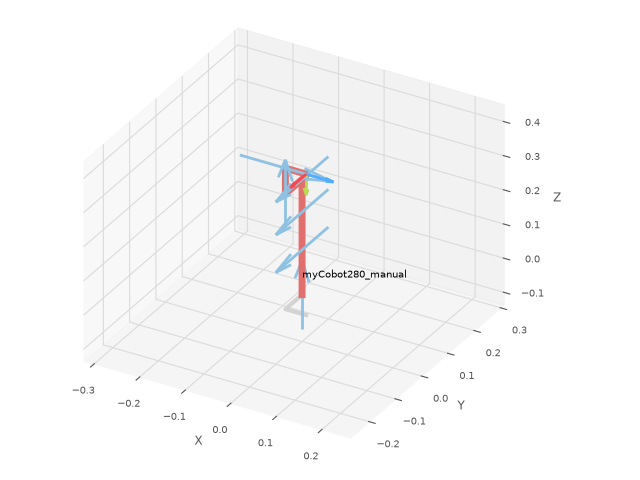

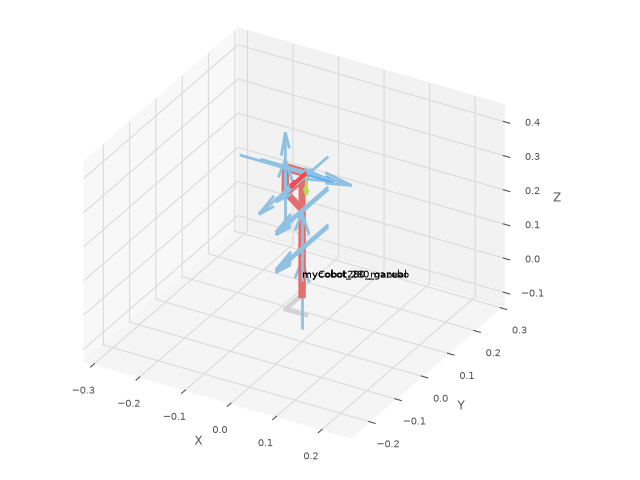

2

In [12]:
home = [0, 0, 0, 0, 0, 0]

robot_fig = manual_robot.plot(home, backend="pyplot")
robot_fig.add(urdf_robot)


### 12. Compare the transforms in terms of end-effector position and orientation
Use `fkine(config).A` to compare the transform from the simplified manual DH model base to your manual tool frame and the transform from `g_base` to `joint6_flange` in the URDF model at home configuration. Compare translation and orientation separately. Small discrepancies can come from the modeling convention itself and, in the full controller stack, from calibrated base/tool correction terms. Note: you can extract the homogeneous transform as a NumPy array from the `.A` member of the transform object.

In [13]:
home = [0, 0, 0, 0, 0, 0]
# Transform from the manual base to the manual tool frame
thome = manual_robot.fkine(home).A
print(thome)

# Transform from g_base to joint6_flange in the URDF-based model
# Hint: compute the URDF-model forward-kinematics pose and verify that the start/end links
# correspond to 'g_base' and 'joint6_flange' (check urdf_robot.base_link
# and urdf_robot.ee_links[0] to confirm).
urdf_home = urdf_robot.fkine(home, start='g_base', end='joint6_flange').A
print(urdf_home)

# Compare translation and orientation separately.


[[-6.12323400e-17  1.83697020e-16  1.00000000e+00  4.56000000e-02]
 [-1.00000000e+00 -3.74939946e-33 -6.12323400e-17 -6.34000000e-02]
 [-7.49879891e-33 -1.00000000e+00  1.83697020e-16  4.12670000e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[[ 0.00000000e+00 -3.67319161e-06  1.00000000e+00  4.56000351e-02]
 [-1.00000000e+00  3.67321860e-06  1.34924357e-11 -6.36210270e-02]
 [-3.67321860e-06 -1.00000000e+00 -3.67319161e-06  4.18139766e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### 13. Verify FK at a known configuration
Evaluate both models at the configuration $\boldsymbol{q} = [0,\; -\pi/2,\; 0,\; 0,\; 0,\; 0]$ and compare the resulting end-effector positions. This gives you a numerical sanity check before moving on.

In [14]:
q_test = [0, -np.pi/2, 0, 0, 0, 0]

t_manual = manual_robot.fkine(q_test).A
# Confirm the URDF chain runs from g_base to joint6_flange:
print("URDF base link:", urdf_robot.base_link)
print("URDF EE link:", urdf_robot.ee_links[0])
t_urdf = urdf_robot.fkine(q_test).A

print("Manual FK end-effector position (m):", t_manual[:3, 3])
print("URDF FK end-effector position (m):", t_urdf[:3, 3])
print("Position difference (mm):", np.linalg.norm(t_manual[:3, 3] - t_urdf[:3, 3]) * 1000)

URDF base link: Link("world")
URDF EE link: Link("joint6_flange", SE3(0, 0.0456, 0; -90°, -0°, 0°) ⊕ Rz(q), parent="joint6", qlim=[-3.14, 3.14], m=0.025, r=[0, 0, 0], I=[6e-06, 7e-06, 1.1e-05, 0, 0, 0], Jm=0, B=0.01, Tc=[0, 0], G=0)
Manual FK end-effector position (m): [ 0.28145 -0.0634   0.08562]
URDF FK end-effector position (m): [ 0.27957977 -0.06362069  0.0929595 ]
Position difference (mm): 7.577249015871109


### 14. Transform between the end-effector frames in Euler angles
If your simplified manual DH model and the URDF model differ in end-effector orientation, compute the relative transform

$\boldsymbol{H}_d = \boldsymbol{H}_{ee,manual}^{-1} \boldsymbol{H}_{ee,urdf}$

This is the same type of frame-comparison task you practiced in the Lab 1 notebook.

In [15]:
# determine the transform between the manual tool frame and joint6_flange
delta = np.linalg.inv(thome) @ urdf_home
print(delta)

[[ 1.00000000e+00 -3.67321860e-06 -1.34924970e-11  2.21026955e-04]
 [ 3.67321860e-06  1.00000000e+00  3.67319161e-06 -5.46976631e-03]
 [ 6.12316652e-17 -3.67319161e-06  1.00000000e+00  3.51120686e-08]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


Convert the relative orientation to roll-pitch-yaw angles and interpret which axis conventions differ between the two end-effector frames.

In [16]:
# convert the relative transform to RPY angles: roll, pitch, yaw
euldelta = tr2rpy(delta, order='zyx')

print(euldelta)

[-3.67319161e-06 -6.12316652e-17  3.67321860e-06]


### 15. Compensate the orientation discrepancy
Use `delta` as a candidate tool correction for the simplified manual DH model by updating `manual_robot.tool`. This mirrors the idea that the full myCobot control stack can contain small base/tool correction terms in addition to the pure URDF chain.

In [17]:
# apply the correction to the manual end-effector frame
manual_robot.tool = manual_tool * SE3(delta)
# thome after orientation compensation
thome = manual_robot.fkine(home).A
print(thome)

[[ 0.00000000e+00 -3.67319161e-06  1.00000000e+00  4.56000351e-02]
 [-1.00000000e+00  3.67321860e-06  1.34924357e-11 -6.36210270e-02]
 [-3.67321860e-06 -1.00000000e+00 -3.67319161e-06  4.18139766e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


### 16. Compare both models
Plot both models again and check whether the corrected manual tool frame is closer to the URDF end-effector frame. In the remaining tasks, use the URDF model as the reference kinematic model for the live ROS 2 controller stack.

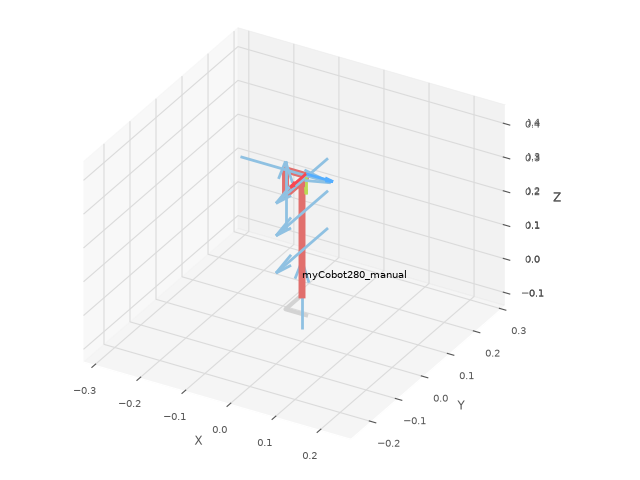

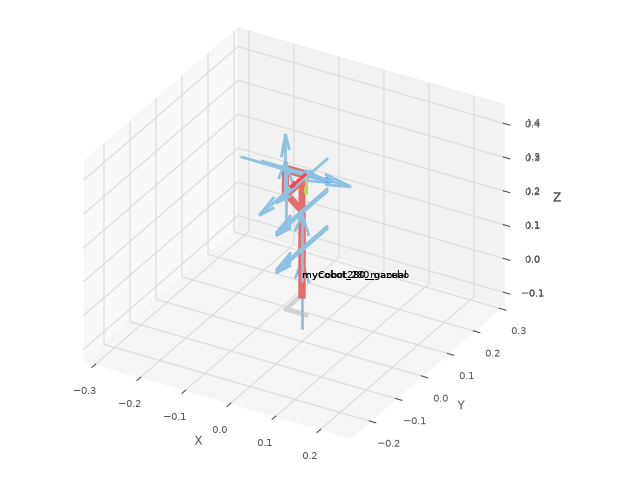

The manual myCobot 280 model and the URDF model agree at the end effector.


In [18]:
home = [0, 0, 0, 0, 0, 0]

robot_2 = manual_robot.plot(home, backend="pyplot")
robot_2.add(urdf_robot)

if np.linalg.norm(thome - urdf_home) < 1.0e-7:
    print('The manual myCobot 280 model and the URDF model agree at the end effector.')
else:
    print('The manual myCobot 280 model and the URDF model still differ at the end effector.')

### 17. Create a random configuration
Create a random configuration of the URDF model with `random_q()`. Compare the end-effector transform of the corrected manual DH model and the URDF-based myCobot 280 model at that configuration.

The manual myCobot 280 model and the URDF model do not fully agree at the end effector.


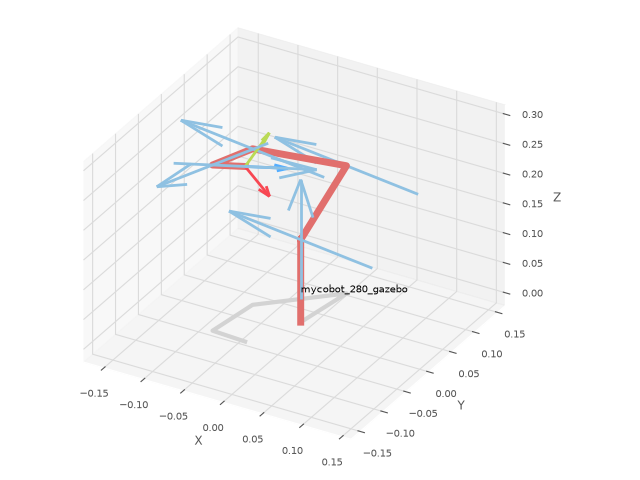

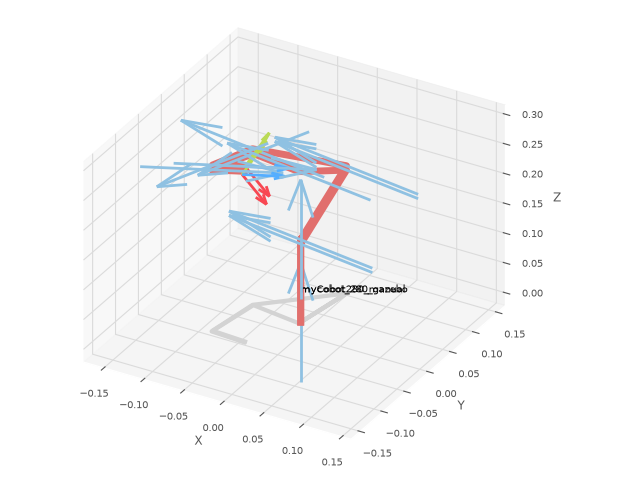

2

In [19]:
# generate a random myCobot 280 configuration
randq = urdf_robot.random_q()

# reuse the same joint vector for both models
urdf_randq = randq

# Transform from base to end effector
trandq = manual_robot.fkine(randq).A
# Compute the corresponding URDF-model end-effector transform for the same joint vector
urdf_trandq = urdf_robot.fkine(urdf_randq, start='g_base', end='joint6_flange').A

if np.linalg.norm(trandq - urdf_trandq) < 1.0e-7:
    print('The manual myCobot 280 model and the URDF model agree at the end effector.')
else:
    print('The manual myCobot 280 model and the URDF model do not fully agree at the end effector.')

# Plot
robot_3 = urdf_robot.plot(urdf_randq, backend='pyplot')
manual_robot.q = randq
robot_3.add(manual_robot)



## ROS 2 Integration for the myCobot 280
Run the remaining tasks from the same activated environment used for Jupyter: `source ~/venvs/mycobot/bin/activate`

The control stack for the labs is launched with `ros2 launch mycobot_control mycobot_control.launch.py`.


### 18. Launch the myCobot control stack
Open a separate terminal, activate `~/venvs/mycobot`, and launch the controller:

```bash
source ~/venvs/mycobot/bin/activate
ros2 launch mycobot_control mycobot_control.launch.py
```

Keep that process running while you inspect topics and publish commands from this notebook.

### 19. Inspect the ROS 2 interfaces
Use the ROS 2 CLI to inspect the live interfaces used in the lab stack:

```bash
ros2 topic list
ros2 topic info /mycobot/joint_states
ros2 topic info /mycobot/joint_command
ros2 topic info /mycobot/joint_velocity
ros2 topic info /mycobot/ee_pose
ros2 interface show sensor_msgs/msg/JointState
ros2 interface show std_msgs/msg/Float64MultiArray
```

### 20. Visualize in RViz2
Open a second terminal, activate the environment, and launch RViz2:

```bash
source ~/venvs/mycobot/bin/activate
rviz2
```

In RViz2:

1. Set **Fixed Frame** to `g_base` in the Global Options panel.
2. Click **Add** → **By display type** → **RobotModel**.
3. Under the RobotModel display, set **Description Source** to **File** and load `mycobot_280_gazebo.urdf` from the same folder as this notebook. The lab controller stack does not publish `/robot_description`, so the URDF must be loaded manually.
4. Click **Add** → **By topic** → select `/mycobot/joint_states` → **TF**.

You should see the myCobot 280 model in its current configuration. When you publish joint commands in the later tasks (Tasks 28–29), the RViz2 model will update in real time alongside the notebook, giving you a co-simulation view of the robot.

If the model does not appear, verify that the controller launch from Task 18 is still running and that `ros2 topic echo /mycobot/joint_states --once` returns data.

## ROS 2 Node and Topics
### 21. Observe state and identify command topics
Confirm that `/mycobot/joint_states` is published by the controller as `JointState`. The active command topics for later labs are `/mycobot/joint_command`, `/mycobot/joint_velocity`, and `/mycobot/ee_pose`, all using `Float64MultiArray`. The controller publishes joint names `joint1` through `joint6` in the `JointState` message. The `.position` field contains the six joint angles in radians. The `/mycobot/ee_pose` command topic expects `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`. The controller converts these to metres and radians internally before solving IK. This topic is used in later labs.

In [20]:
import time

import rclpy
from rclpy.node import Node
from sensor_msgs.msg import JointState
from std_msgs.msg import Float64MultiArray


class MyCobotNotebookNode(Node):
    def __init__(self):
        super().__init__('mycobot_fk_notebook')
        self.last_joint_state = None
        self.joint_state_sub = self.create_subscription(
            JointState,
            '/mycobot/joint_states',
            self.joint_state_callback,
            10,
        )

    def joint_state_callback(self, msg):
        self.last_joint_state = msg


### 22. Initialize a ROS 2 notebook node
Initialize `rclpy`, create a small notebook node, and spin it briefly whenever you want to process incoming `/mycobot/joint_states` messages.

In [21]:
if not rclpy.ok():
    rclpy.init(args=None)

node = MyCobotNotebookNode()

### 23. Query the topics that are currently available
Use the ROS 2 CLI from a terminal or a Jupyter shell cell to inspect the active topics. Then spin the notebook node once and check whether a `JointState` message arrives on `/mycobot/joint_states`.

In [22]:
# Terminal commands
# !ros2 topic list
# !ros2 topic info /mycobot/joint_states
# !ros2 topic info /mycobot/joint_command
# !ros2 topic echo /mycobot/joint_states --once
# !ros2 interface show sensor_msgs/msg/JointState
# !ros2 interface show std_msgs/msg/Float64MultiArray

rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)


None


## ROS 2 Subscriber and Publisher
### 24. Create a publisher
The controller already publishes `/mycobot/joint_states`, so do not publish to that topic. Instead, create a publisher for `/mycobot/joint_command` with the message type `std_msgs/msg/Float64MultiArray`.

In [23]:
joint_command_publisher = node.create_publisher(
    Float64MultiArray,
    '/mycobot/joint_command',
    10,
)


### 25. Create an empty command message
Create an empty `Float64MultiArray` message for `/mycobot/joint_command` and inspect its field structure. The controller publishes measured or estimated joint states on `/mycobot/joint_states`; this notebook sends desired joint positions on `/mycobot/joint_command`.

In [24]:
joint_command_msg = Float64MultiArray()
print(joint_command_msg)

std_msgs.msg.Float64MultiArray(layout=std_msgs.msg.MultiArrayLayout(dim=[], data_offset=0), data=[])


### 26. Assign a joint vector to the message
Copy a 6-element joint configuration into the `.data` field of the command message. You can use `randq` from the previous section or define a simple test configuration that stays within the safe lab workspace.

**Important:** The `/mycobot/joint_command` topic expects joint angles in radians. The controller internally converts to degrees before sending to the hardware.

In [25]:
q_cmd = np.zeros(6)
joint_command_msg.data = q_cmd.tolist()

### 27. Inspect the observed joint state
Spin the notebook node once and inspect the latest `/mycobot/joint_states` message. Compare the observed state topic with the joint-position command vector you are about to send.

In [26]:
rclpy.spin_once(node, timeout_sec=0.5)
print(node.last_joint_state)

None


### 28. Publish joint-position commands
Publish the `Float64MultiArray` command on `/mycobot/joint_command`. The controller should interpret this as a desired joint-position command for the myCobot 280.

In [27]:
joint_command_publisher.publish(joint_command_msg)

If the robot or visualization does not respond, make sure the controller launch is running from the same `~/venvs/mycobot` environment and verify the topic names again with `ros2 topic list`.

### 29. Publish a simple interpolated joint-space trajectory
Implement a notebook-friendly loop that sends intermediate joint-position commands
\begin{equation}
\boldsymbol{q}_t = \boldsymbol{q}_i + (\boldsymbol{q}_f - \boldsymbol{q}_i) \frac{t}{t_f}
\end{equation}
from an initial configuration `qi` to a target configuration `qf` over a duration `t_f`. Publish the interpolated vectors on `/mycobot/joint_command` and optionally inspect `/mycobot/joint_states` during the loop. This linear interpolation is a simple baseline. Lab 6 (Trajectory Planning) replaces it with smoother trapezoidal and polynomial velocity profiles that respect acceleration limits.

In [28]:
go_into_loop = True

publish_ros2 = True

if go_into_loop:
    rate_hz = 20.0
    dt = 1.0 / rate_hz
    max_time = 4.0

    # prepare loop
    # /mycobot/joint_command expects joint angles in radians
    qi = np.array([0, 0, 0, 0, 0, 0], dtype=float)
    qf = np.array([np.pi / 2, -np.pi / 2, np.pi / 2, 0, np.pi / 3, -np.pi / 3], dtype=float)
    start_time = time.time()
    current_time = time.time()

    while current_time - start_time < max_time:
        current_time = time.time()
        tau = np.clip((current_time - start_time) / max_time, 0.0, 1.0)
        qinterp = qi + (qf - qi) * tau

        if publish_ros2:
            joint_command_msg.data = qinterp.tolist()
            joint_command_publisher.publish(joint_command_msg)
            rclpy.spin_once(node, timeout_sec=0.0)

        time.sleep(dt)

# Optional cleanup at the end of the notebook:
# node.destroy_node()
# rclpy.shutdown()